In [1]:
### File which has all the function to generate the descriptors 
import utilities

In [2]:
import pandas as pd 
## Loading the our train data 

train_set=pd.read_csv( '../data/final_data/final_unique_train.csv')
### Taking out the smiles from train data 
SMILES_train=train_set.smiles_canon
combined_df=utilities.create_feature_multiple(SMILES_train)
### MW 181
SMILES1 = 'CC(=O)OC1=CC=CC=C1C(=O)O'  
single_df1=utilities.create_feature_single(SMILES1)
new_molecule_vector1=utilities.clean_data(single_df1)

[22:24:46] WARNING: not removing hydrogen atom without neighbors
[22:24:46] WARNING: not removing hydrogen atom without neighbors
[22:24:46] WARNING: not removing hydrogen atom without neighbors
[22:24:46] WARNING: not removing hydrogen atom without neighbors
[22:24:46] WARNING: not removing hydrogen atom without neighbors
[22:24:46] WARNING: not removing hydrogen atom without neighbors
[22:24:46] WARNING: not removing hydrogen atom without neighbors
[22:24:46] WARNING: not removing hydrogen atom without neighbors
[22:24:46] WARNING: not removing hydrogen atom without neighbors
[22:24:47] WARNING: not removing hydrogen atom without neighbors
[22:24:47] WARNING: not removing hydrogen atom without neighbors
[22:24:47] WARNING: not removing hydrogen atom without neighbors
[22:24:47] WARNING: not removing hydrogen atom without neighbors
[22:24:47] WARNING: not removing hydrogen atom without neighbors
[22:24:47] WARNING: not removing hydrogen atom without neighbors
[22:24:47] WARNING: not r

In [3]:
### Passing the data to function clean_data which preprocess the data  
training_set_vectors=utilities.clean_data(combined_df)
new_molecule_vector1=utilities.clean_data(single_df1)

/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


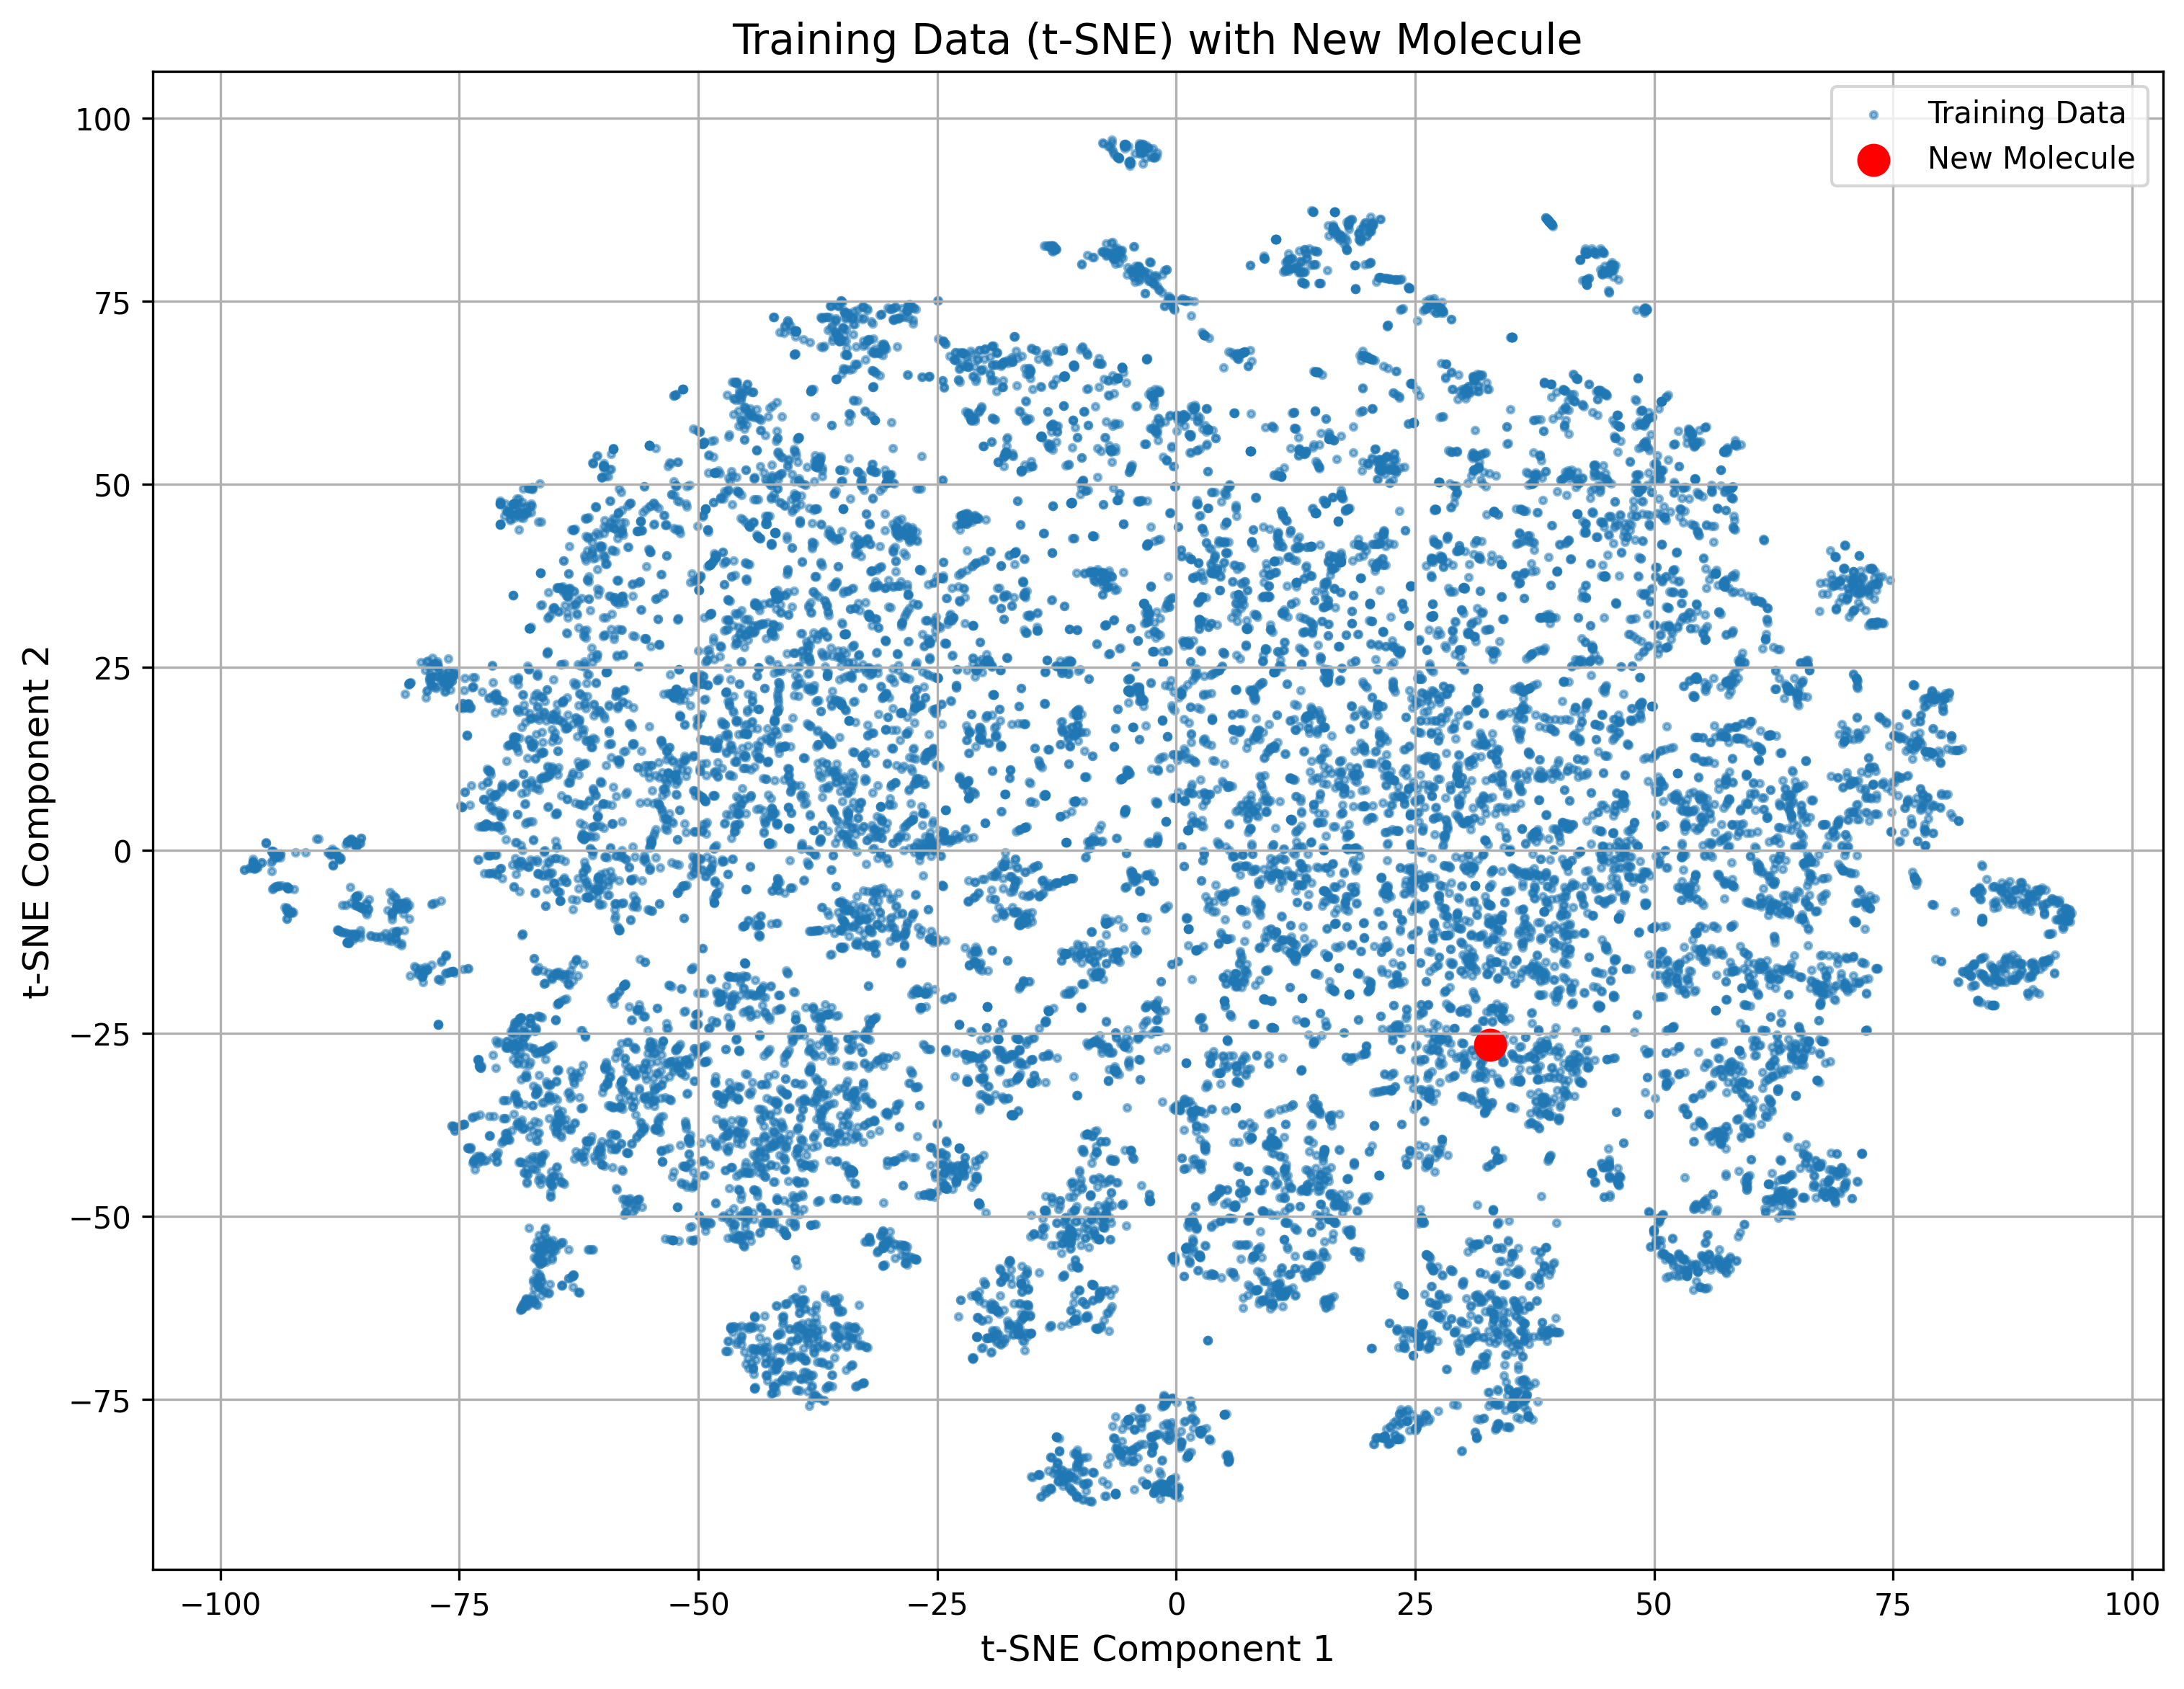

In [4]:
### Creating a t-SNE graph and to analyze where lies the compound with Molecular weight 181 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 🔹 Simulated Data (Replace with actual datasets)
np.random.seed(42)

# Step 1: Standardize the Data
scaler = StandardScaler()
training_set_vectors_scaled = scaler.fit_transform(training_set_vectors)  # Proper Initialization
new_molecule_scaled = scaler.transform(new_molecule_vector1)

# Step 2: Apply PCA for Dimensionality Reduction (to 50 components)
pca = PCA(n_components=50)
training_set_vectors_pca = pca.fit_transform(training_set_vectors_scaled)
new_molecule_pca = pca.transform(new_molecule_scaled)

# Ensure new_molecule_pca is 2D
if new_molecule_pca.ndim == 1:
    new_molecule_pca = new_molecule_pca.reshape(1, -1)

# Step 3: Combine PCA-Reduced Data for t-SNE
combined_vectors_pca = np.vstack([training_set_vectors_pca, new_molecule_pca])

# Step 4: Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
combined_vectors_tsne = tsne.fit_transform(combined_vectors_pca)

# Step 5: Extract t-SNE coordinates
new_molecule_tsne1 = combined_vectors_tsne[-1]  # Last row = New Molecule
training_set_vectors_tsne = combined_vectors_tsne[:-1]  # Rest = Training Data

# Step 6: Plot t-SNE
plt.figure(figsize=(12, 9), dpi=300)
plt.scatter(training_set_vectors_tsne[:, 0], training_set_vectors_tsne[:, 1], s=5, alpha=0.5, label="Training Data")
plt.scatter(new_molecule_tsne1[0], new_molecule_tsne1[1], color='red', label="New Molecule", s=100)

plt.title("Training Data (t-SNE) with New Molecule", fontsize=14)
plt.xlabel("t-SNE Component 1", fontsize=12)
plt.ylabel("t-SNE Component 2", fontsize=12)
plt.legend()
plt.grid(True)

# Save high-resolution figure
plt.savefig("tsne_visualization_181.png", dpi=300, bbox_inches='tight')
plt.show()


In [5]:
## MW 588
SMILES2='[C@H]1(C5=C([C@H](C2[C@@H]1C(OC2)=O)O[C@@H]3O[C@H]4[C@H]([C@@H]([C@H]3O)O)O[C@@H](OC4)C)C=C6C(=C5)OCO6)C7=CC(=C(C(=C7)OC)O)OC'
### Calculating the feature space for this molecule 
single_df2=utilities.create_feature_single(SMILES2)
new_molecule_vector2=utilities.clean_data(single_df2)

/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


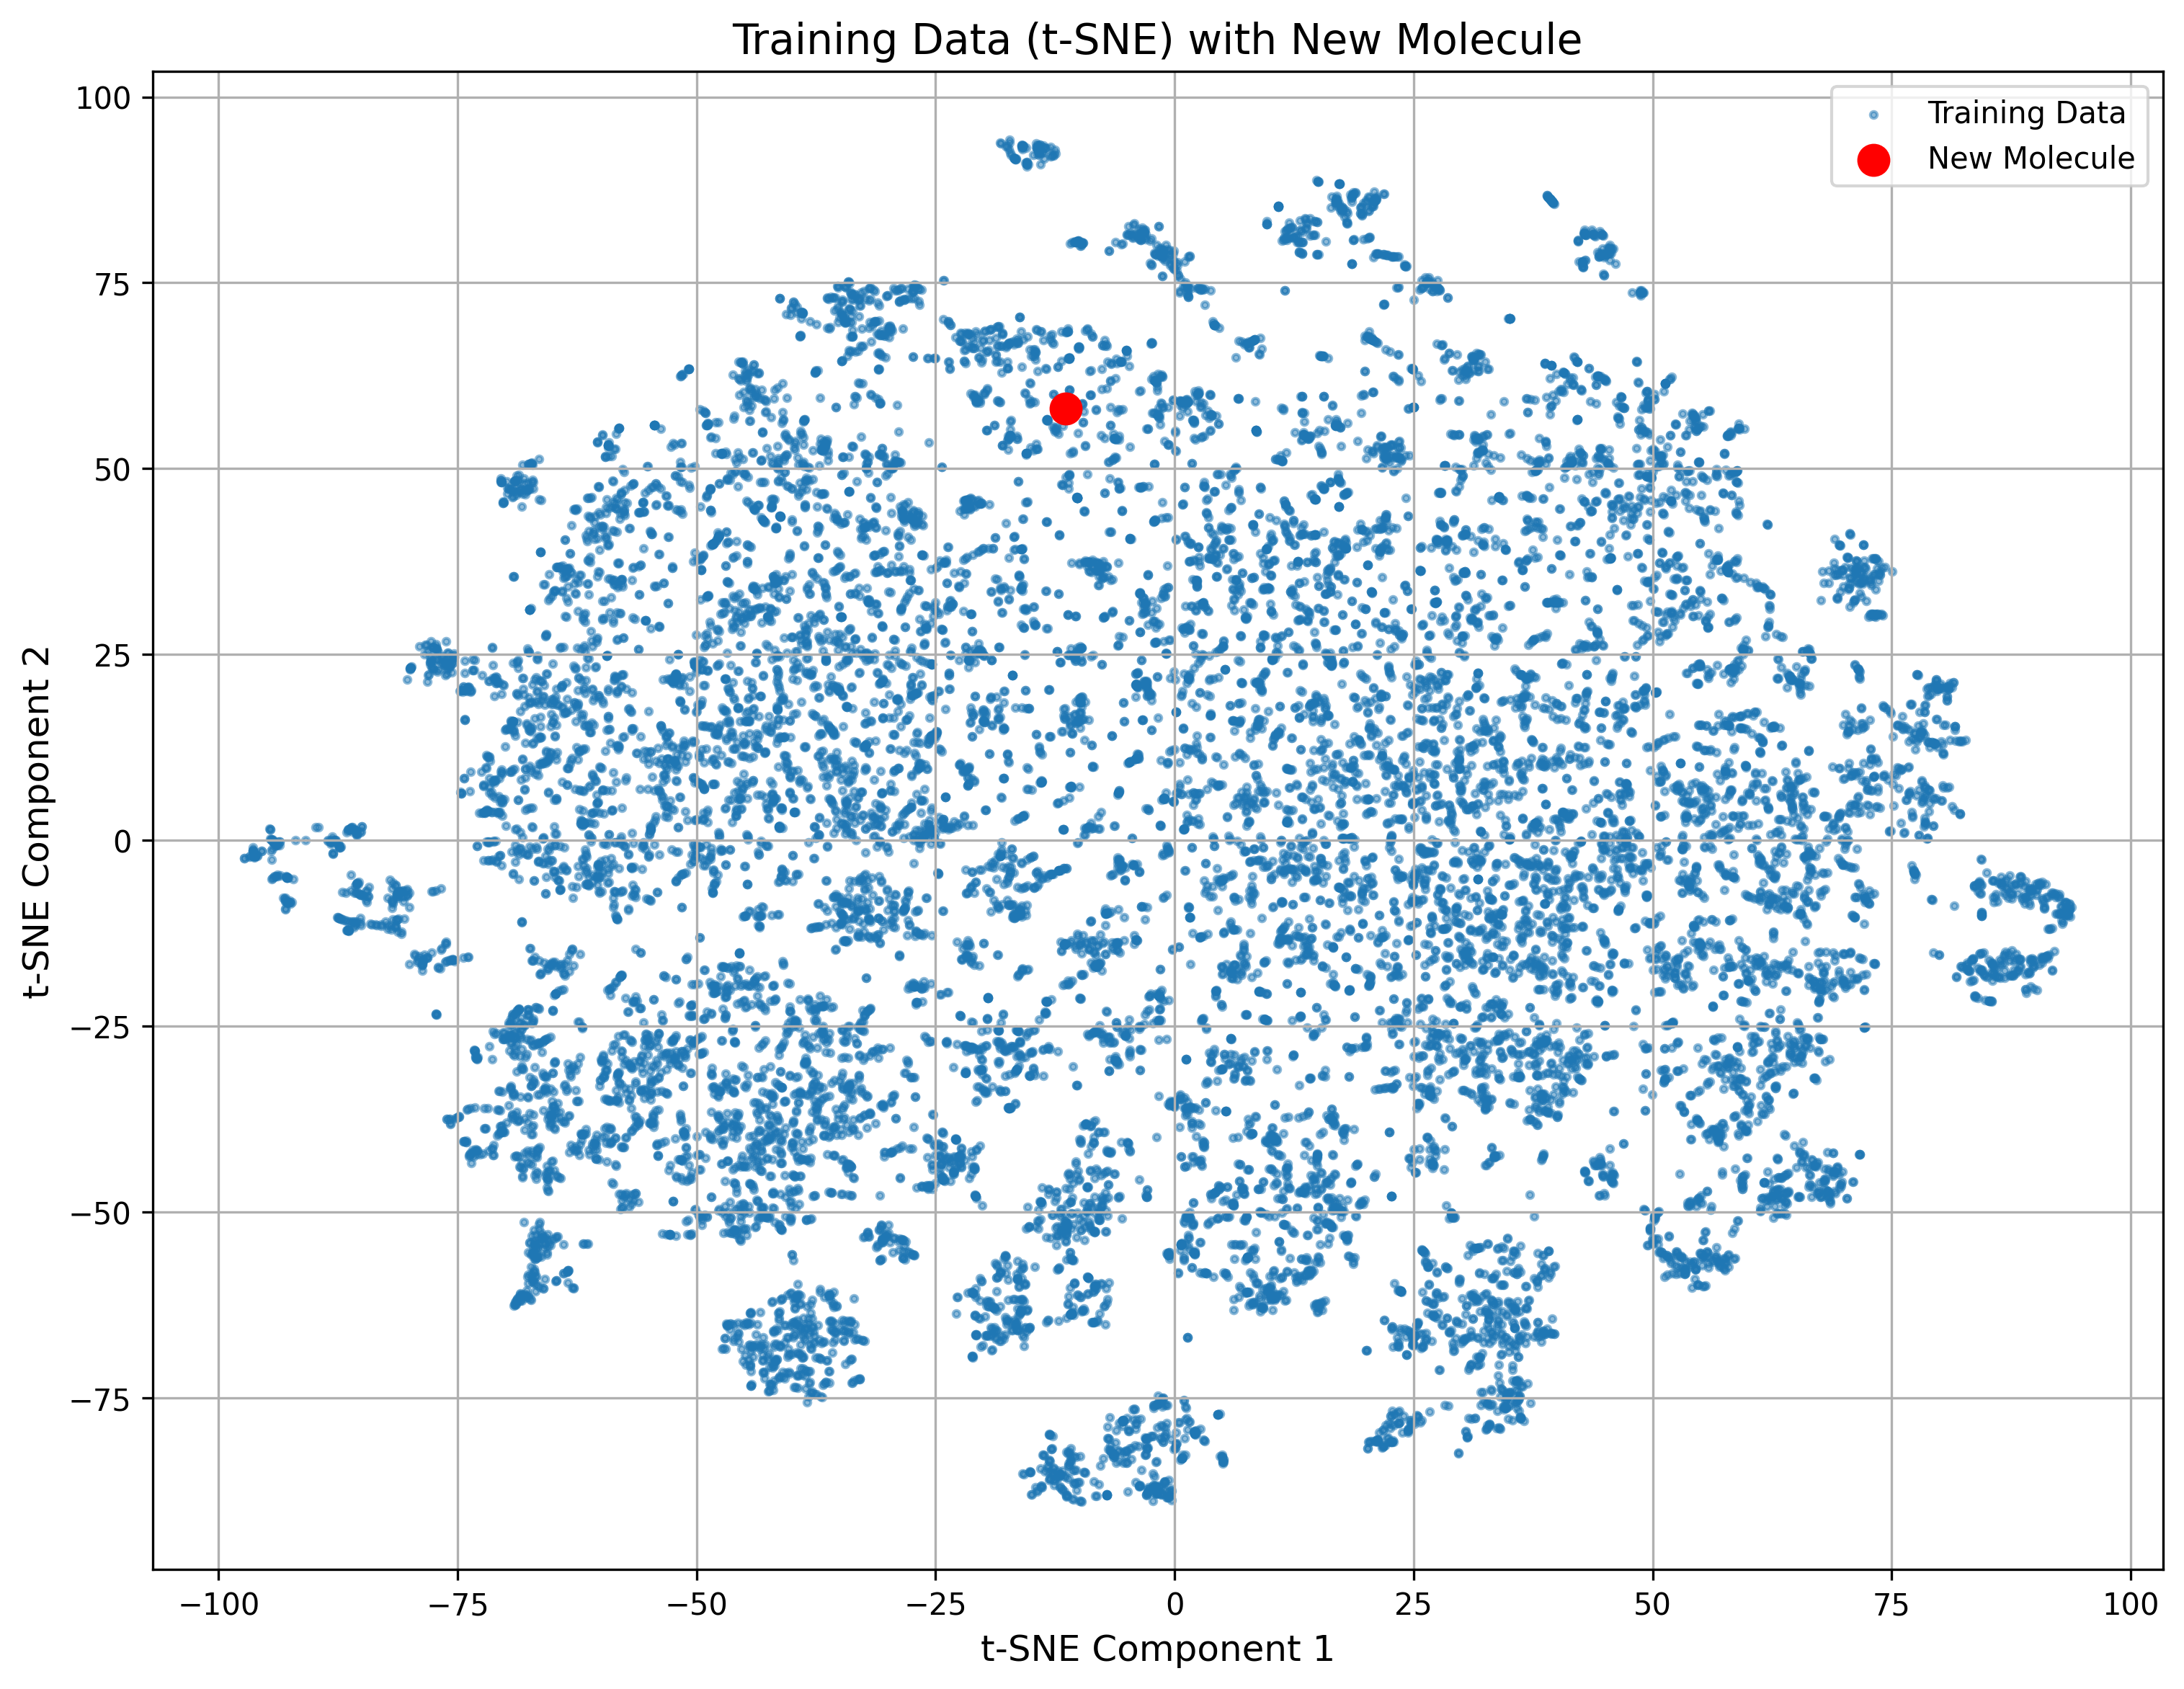

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 🔹 Simulated Data (Replace with actual datasets)
np.random.seed(42)

# Step 1: Standardize the Data
scaler = StandardScaler()
training_set_vectors_scaled = scaler.fit_transform(training_set_vectors)  # ✅ Proper Initialization
new_molecule_scaled = scaler.transform(new_molecule_vector2)

# Step 2: Apply PCA for Dimensionality Reduction (to 50 components)
pca = PCA(n_components=50)
training_set_vectors_pca = pca.fit_transform(training_set_vectors_scaled)
new_molecule_pca = pca.transform(new_molecule_scaled)

# Ensure new_molecule_pca is 2D
if new_molecule_pca.ndim == 1:
    new_molecule_pca = new_molecule_pca.reshape(1, -1)

# Step 3: Combine PCA-Reduced Data for t-SNE
combined_vectors_pca = np.vstack([training_set_vectors_pca, new_molecule_pca])

# Step 4: Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
combined_vectors_tsne = tsne.fit_transform(combined_vectors_pca)

# Step 5: Extract t-SNE coordinates
new_molecule_tsne2 = combined_vectors_tsne[-1]  # Last row = New Molecule
training_set_vectors_tsne = combined_vectors_tsne[:-1]  # Rest = Training Data

# Step 6: Plot t-SNE
plt.figure(figsize=(12, 9), dpi=300)
plt.scatter(training_set_vectors_tsne[:, 0], training_set_vectors_tsne[:, 1], s=5, alpha=0.5, label="Training Data")
plt.scatter(new_molecule_tsne2[0], new_molecule_tsne2[1], color='red', label="New Molecule", s=100)

plt.title("Training Data (t-SNE) with New Molecule", fontsize=14)
plt.xlabel("t-SNE Component 1", fontsize=12)
plt.ylabel("t-SNE Component 2", fontsize=12)
plt.legend()
plt.grid(True)

# Save high-resolution figure
plt.savefig("tsne_visualization_588.png", dpi=300, bbox_inches='tight')
plt.show()


In [7]:
## Molecular weight 1202
SMILES2='CCC1C(=O)N(CC(=O)N(C(C(=O)NC(C(=O)N(C(C(=O)NC(C(=O)NC(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N1)C(C(C)CC=CC)O)C)C(C)C)C)CC(C)C)C)CC(C)C)C)C)C)CC(C)C)C)C(C)C)CC(C)C)C)C'  
single_df2=utilities.create_feature_single(SMILES2)
new_molecule_vector2=utilities.clean_data(single_df2)

/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


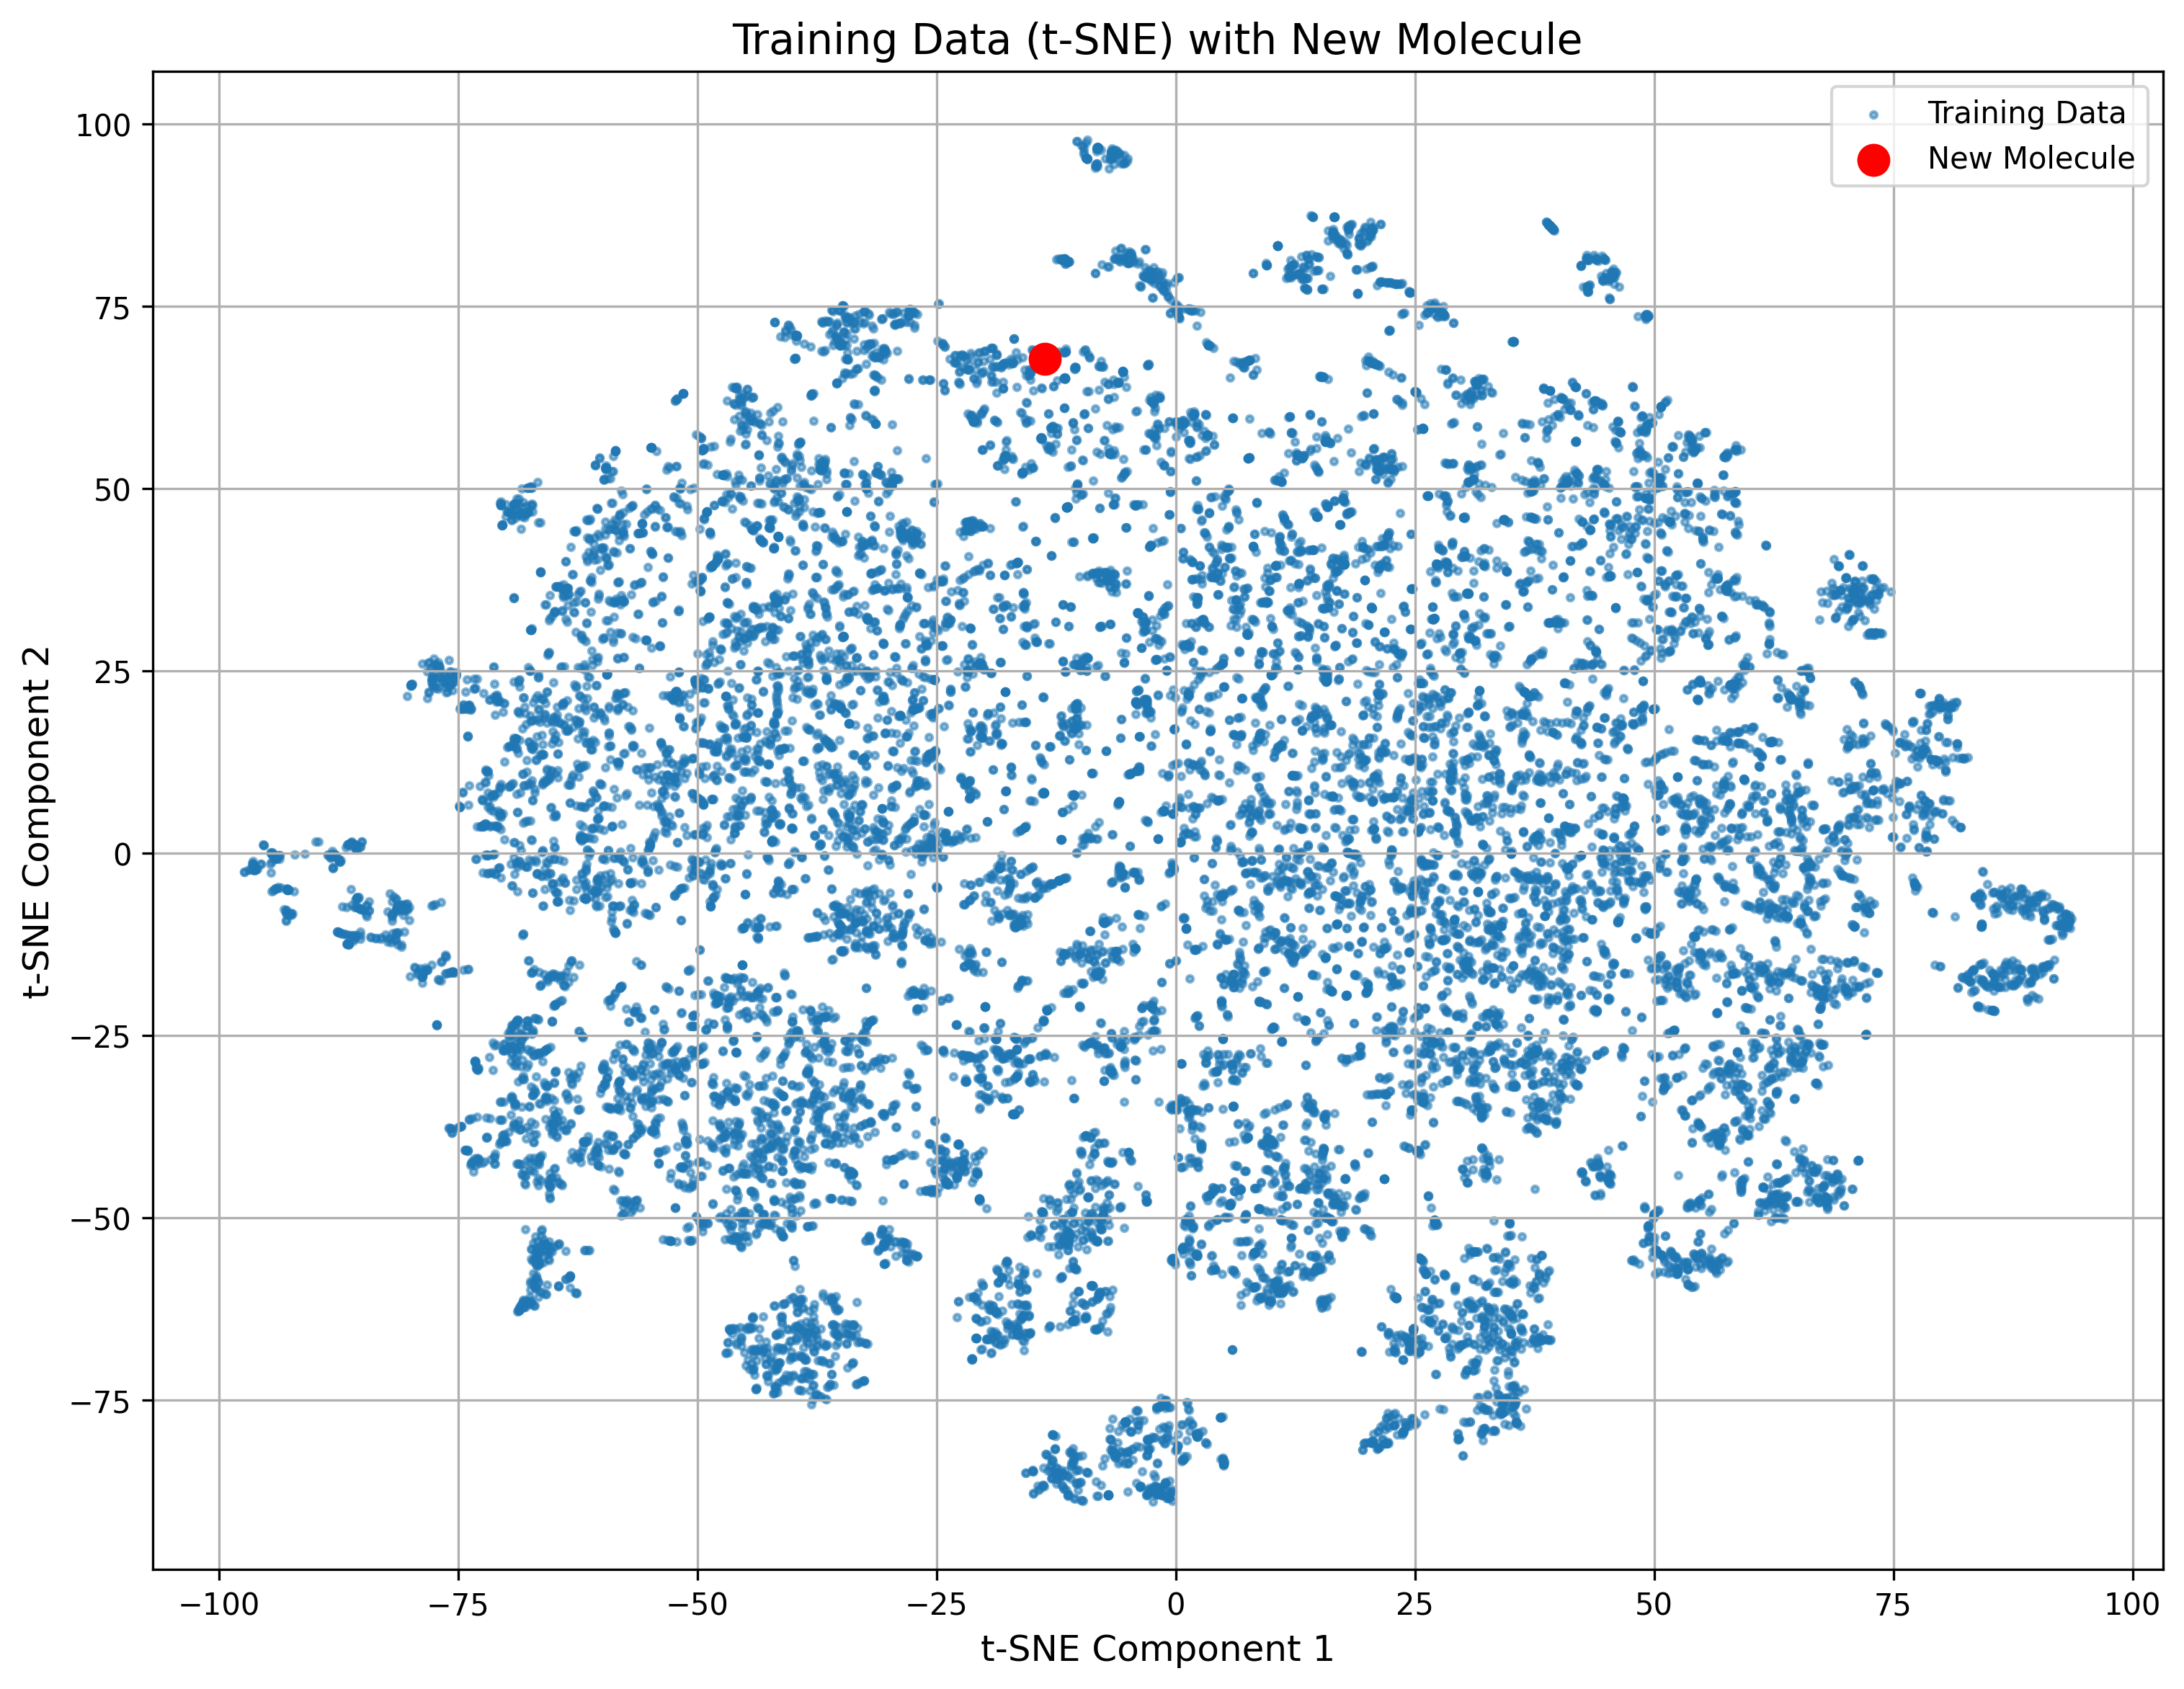

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 🔹 Simulated Data (Replace with actual datasets)
np.random.seed(42)

# Step 1: Standardize the Data
scaler = StandardScaler()
training_set_vectors_scaled = scaler.fit_transform(training_set_vectors)  # ✅ Proper Initialization
new_molecule_scaled = scaler.transform(new_molecule_vector2)

# Step 2: Apply PCA for Dimensionality Reduction (to 50 components)
pca = PCA(n_components=50)
training_set_vectors_pca = pca.fit_transform(training_set_vectors_scaled)
new_molecule_pca = pca.transform(new_molecule_scaled)

# Ensure new_molecule_pca is 2D
if new_molecule_pca.ndim == 1:
    new_molecule_pca = new_molecule_pca.reshape(1, -1)

# Step 3: Combine PCA-Reduced Data for t-SNE
combined_vectors_pca = np.vstack([training_set_vectors_pca, new_molecule_pca])

# Step 4: Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
combined_vectors_tsne = tsne.fit_transform(combined_vectors_pca)

# Step 5: Extract t-SNE coordinates
new_molecule_tsne2 = combined_vectors_tsne[-1]  # Last row = New Molecule
training_set_vectors_tsne = combined_vectors_tsne[:-1]  # Rest = Training Data

# Step 6: Plot t-SNE
plt.figure(figsize=(12, 9), dpi=300)
plt.scatter(training_set_vectors_tsne[:, 0], training_set_vectors_tsne[:, 1], s=5, alpha=0.5, label="Training Data")
plt.scatter(new_molecule_tsne2[0], new_molecule_tsne2[1], color='red', label="New Molecule", s=100)

plt.title("Training Data (t-SNE) with New Molecule", fontsize=14)
plt.xlabel("t-SNE Component 1", fontsize=12)
plt.ylabel("t-SNE Component 2", fontsize=12)
plt.legend()
plt.grid(True)

# Save high-resolution figure
plt.savefig("tsne_visualization_1202.png", dpi=300, bbox_inches='tight')
plt.show()


/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


New molecule Mahalanobis distance (PCA space): 1.014
Applicability threshold (95th percentile): 2.953
New molecule is WITHIN the applicability domain!


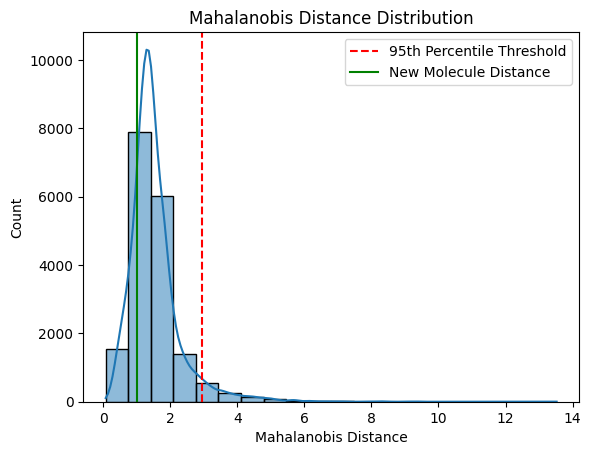

In [9]:
## for molecular weight  181 compounds  checking its in our application domain or not 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
from scipy.spatial.distance import mahalanobis
from scipy.stats import median_abs_deviation

###creating vector for new compound 
SMILES1 = 'CC(=O)OC1=CC=CC=C1C(=O)O'  
single_df1=utilities.create_feature_single(SMILES1)
new_molecule_vector=utilities.clean_data(single_df1)


### Standardize Data (Important for PCA & Mahalanobis)
scaler = StandardScaler()
training_set_vectors_scaled = scaler.fit_transform(training_set_vectors)
new_molecule_vector_scaled = scaler.transform(new_molecule_vector)


# Compute t-SNE Embeddings (Only for Visualization)

tsne = TSNE(n_components=3, random_state=42, perplexity=50)
training_set_vectors_tsne3 = tsne.fit_transform(training_set_vectors_scaled)


# Reduce Dimensionality with PCA for Mahalanobis Distance

pca = PCA(n_components=3)  # Use 3D PCA for meaningful distance calculations
training_set_vectors_pca3 = pca.fit_transform(training_set_vectors_scaled)


# Approximate New Molecule PCA Coordinates Using k-NN Regression

knn = KNeighborsRegressor(n_neighbors=5, weights="uniform")
knn.fit(training_set_vectors_scaled, training_set_vectors_pca3)
new_molecule_pca3 = knn.predict(new_molecule_vector_scaled).flatten()


# Compute Mahalanobis Distance in PCA Space

# Compute covariance matrix using Ledoit-Wolf for stability
cov_matrix = LedoitWolf().fit(training_set_vectors_pca3).covariance_
inv_cov_matrix = np.linalg.inv(cov_matrix)

# Compute mean in PCA space
mean_pca = np.mean(training_set_vectors_pca3, axis=0)

# Compute Mahalanobis distances of training molecules
distances = [mahalanobis(t, mean_pca, inv_cov_matrix) for t in training_set_vectors_pca3]

# Compute Mahalanobis distance of new molecule
new_molecule_distance = mahalanobis(new_molecule_pca3, mean_pca, inv_cov_matrix)


#  Compute Applicability Domain Threshold

# Compute 90th percentile instead of MAD for better robustness
threshold_distance = np.percentile(distances, 95)


# Decision Based on Mahalanobis Distance

print(f"New molecule Mahalanobis distance (PCA space): {new_molecule_distance:.3f}")
print(f"Applicability threshold (95th percentile): {threshold_distance:.3f}")

if new_molecule_distance > threshold_distance:
    print("New molecule is OUTSIDE the applicability domain!")
else:
    print("New molecule is WITHIN the applicability domain!")

# Plot Mahalanobis Distance Distribution

sns.histplot(distances, bins=20, kde=True)
plt.axvline(threshold_distance, color='red', linestyle='dashed', label="95th Percentile Threshold")
plt.axvline(new_molecule_distance, color='green', linestyle='solid', label="New Molecule Distance")
plt.xlabel("Mahalanobis Distance")
plt.ylabel("Count")
plt.legend()
plt.title("Mahalanobis Distance Distribution")
plt.show()

/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


New molecule Mahalanobis distance (PCA space): 7.059
Applicability threshold (95th percentile): 2.953
New molecule is OUTSIDE the applicability domain!


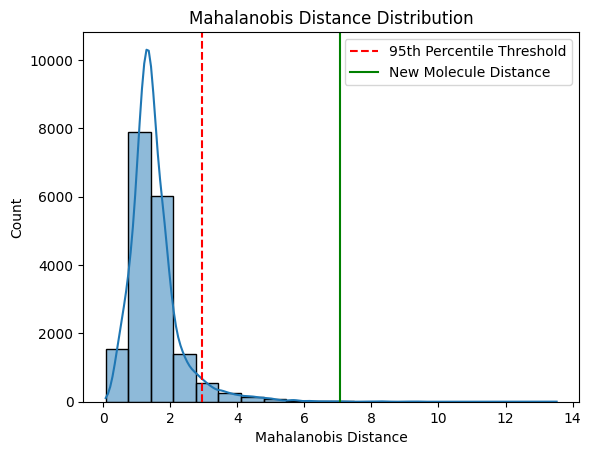

In [10]:
## ## for molecular weight  1202 compounds  checking its in our application domain or not 
import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
from scipy.spatial.distance import mahalanobis
from scipy.stats import median_abs_deviation
import matplotlib.pyplot as plt

SMILES='CCC1C(=O)N(CC(=O)N(C(C(=O)NC(C(=O)N(C(C(=O)NC(C(=O)NC(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N1)C(C(C)CC=CC)O)C)C(C)C)C)CC(C)C)C)CC(C)C)C)C)C)CC(C)C)C)C(C)C)CC(C)C)C)C'  
single_df=utilities.create_feature_single(SMILES)
new_molecule_vector=utilities.clean_data(single_df)


# Standardize Data (Important for PCA & Mahalanobis)

scaler = StandardScaler()
training_set_vectors_scaled = scaler.fit_transform(training_set_vectors)
new_molecule_vector_scaled = scaler.transform(new_molecule_vector)


# Compute t-SNE Embeddings (Only for Visualization)

tsne = TSNE(n_components=3, random_state=42, perplexity=50)
training_set_vectors_tsne3 = tsne.fit_transform(training_set_vectors_scaled)


# Reduce Dimensionality with PCA for Mahalanobis Distance

pca = PCA(n_components=3)  # Use 3D PCA for meaningful distance calculations
training_set_vectors_pca3 = pca.fit_transform(training_set_vectors_scaled)


#  Approximate New Molecule PCA Coordinates Using k-NN Regression

knn = KNeighborsRegressor(n_neighbors=5, weights="uniform")
knn.fit(training_set_vectors_scaled, training_set_vectors_pca3)
new_molecule_pca3 = knn.predict(new_molecule_vector_scaled).flatten()


# 6Compute Mahalanobis Distance in PCA Space

# Compute covariance matrix using Ledoit-Wolf for stability
cov_matrix = LedoitWolf().fit(training_set_vectors_pca3).covariance_
inv_cov_matrix = np.linalg.inv(cov_matrix)

# Compute mean in PCA space
mean_pca = np.mean(training_set_vectors_pca3, axis=0)

# Compute Mahalanobis distances of training molecules
distances = [mahalanobis(t, mean_pca, inv_cov_matrix) for t in training_set_vectors_pca3]

# Compute Mahalanobis distance of new molecule
new_molecule_distance = mahalanobis(new_molecule_pca3, mean_pca, inv_cov_matrix)


# Compute Applicability Domain Threshold

# Compute 95th percentile instead of MAD for better robustness
threshold_distance = np.percentile(distances, 95)


# Decision Based on Mahalanobis Distance

print(f"New molecule Mahalanobis distance (PCA space): {new_molecule_distance:.3f}")
print(f"Applicability threshold (95th percentile): {threshold_distance:.3f}")

if new_molecule_distance > threshold_distance:
    print("New molecule is OUTSIDE the applicability domain!")
else:
    print("New molecule is WITHIN the applicability domain!")

# Plot Mahalanobis Distance Distribution

sns.histplot(distances, bins=20, kde=True)
plt.axvline(threshold_distance, color='red', linestyle='dashed', label="95th Percentile Threshold")
plt.axvline(new_molecule_distance, color='green', linestyle='solid', label="New Molecule Distance")
plt.xlabel("Mahalanobis Distance")
plt.ylabel("Count")
plt.legend()
plt.title("Mahalanobis Distance Distribution")
plt.show()

/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


New molecule Mahalanobis distance (PCA space): 2.277
Applicability threshold (95th percentile): 2.953
New molecule is WITHIN the applicability domain!


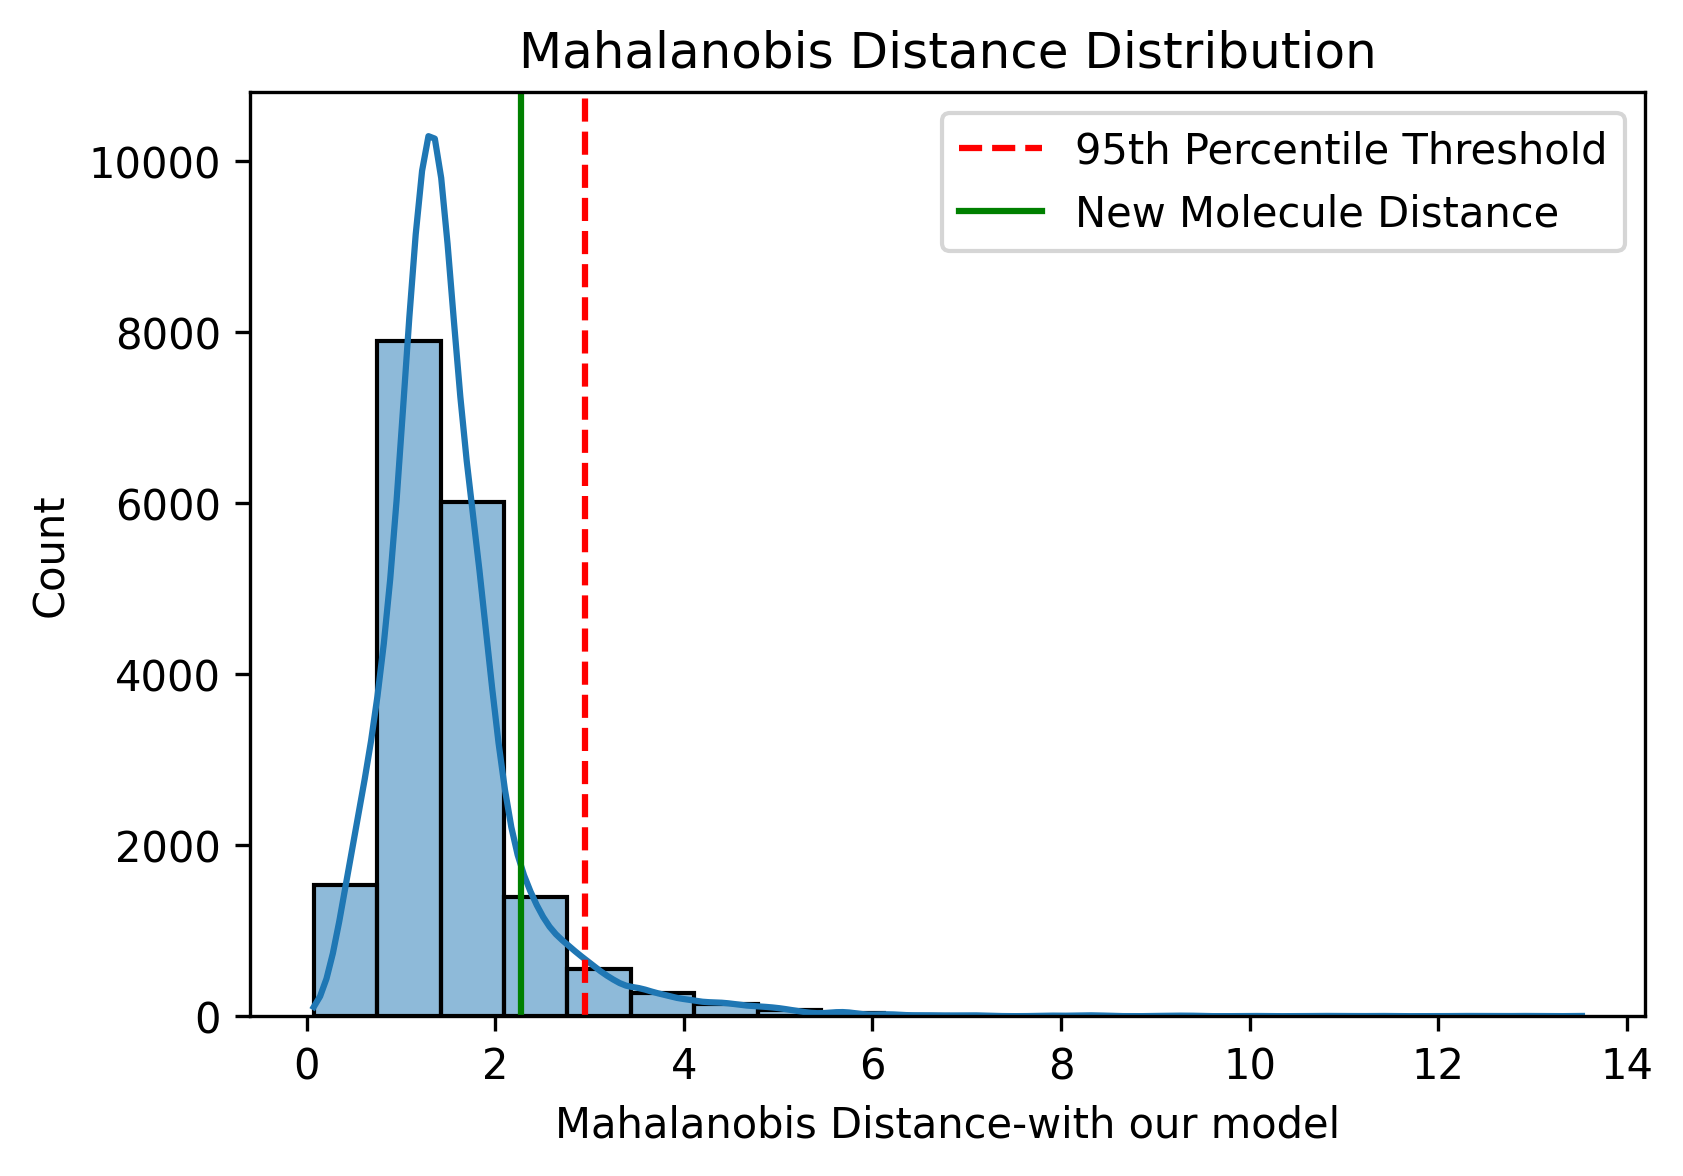

In [11]:
## for mw 588
import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
from scipy.spatial.distance import mahalanobis
from scipy.stats import median_abs_deviation

###creating vector for new compound 
SMILES='[C@H]1(C5=C([C@H](C2[C@@H]1C(OC2)=O)O[C@@H]3O[C@H]4[C@H]([C@@H]([C@H]3O)O)O[C@@H](OC4)C)C=C6C(=C5)OCO6)C7=CC(=C(C(=C7)OC)O)OC'
single_df=utilities.create_feature_single(SMILES)
new_molecule_vector=utilities.clean_data(single_df)


### Standardize Data (Important for PCA & Mahalanobis)

scaler = StandardScaler()
training_set_vectors_scaled = scaler.fit_transform(training_set_vectors)
new_molecule_vector_scaled = scaler.transform(new_molecule_vector)


# Compute t-SNE Embeddings (Only for Visualization)

tsne = TSNE(n_components=3, random_state=42, perplexity=50)
training_set_vectors_tsne3 = tsne.fit_transform(training_set_vectors_scaled)


# Reduce Dimensionality with PCA for Mahalanobis Distance

pca = PCA(n_components=3)  # Use 3D PCA for meaningful distance calculations
training_set_vectors_pca3 = pca.fit_transform(training_set_vectors_scaled)


# Approximate New Molecule PCA Coordinates Using k-NN Regression

knn = KNeighborsRegressor(n_neighbors=5, weights="uniform")
knn.fit(training_set_vectors_scaled, training_set_vectors_pca3)
new_molecule_pca3 = knn.predict(new_molecule_vector_scaled).flatten()


# Compute Mahalanobis Distance in PCA Space

# Compute covariance matrix using Ledoit-Wolf for stability
cov_matrix = LedoitWolf().fit(training_set_vectors_pca3).covariance_
inv_cov_matrix = np.linalg.inv(cov_matrix)

# Compute mean in PCA space
mean_pca = np.mean(training_set_vectors_pca3, axis=0)

# Compute Mahalanobis distances of training molecules
distances = [mahalanobis(t, mean_pca, inv_cov_matrix) for t in training_set_vectors_pca3]

# Compute Mahalanobis distance of new molecule
new_molecule_distance = mahalanobis(new_molecule_pca3, mean_pca, inv_cov_matrix)


#  Compute Applicability Domain Threshold

# Compute 90th percentile instead of MAD for better robustness
threshold_distance = np.percentile(distances, 95)


# 8️⃣ Decision Based on Mahalanobis Distance

print(f"New molecule Mahalanobis distance (PCA space): {new_molecule_distance:.3f}")
print(f"Applicability threshold (95th percentile): {threshold_distance:.3f}")

if new_molecule_distance > threshold_distance:
    print("New molecule is OUTSIDE the applicability domain!")
else:
    print("New molecule is WITHIN the applicability domain!")

# Plot Mahalanobis Distance Distribution

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Force full transparency
fig.patch.set_alpha(0)  # Make the entire figure background transparent
ax.set_facecolor("none")  # Remove background color from axes

sns.histplot(distances, bins=20, kde=True)
plt.axvline(threshold_distance, color='red', linestyle='dashed', label="95th Percentile Threshold")
plt.axvline(new_molecule_distance, color='green', linestyle='solid', label="New Molecule Distance")
plt.xlabel("Mahalanobis Distance-with our model")
plt.ylabel("Count")
plt.legend()
plt.title("Mahalanobis Distance Distribution")
plt.savefig(
    "mahalanobis_distance_our_model.png",
    dpi=300,
    bbox_inches='tight',
    transparent=True,
    facecolor=fig.get_facecolor()  # Ensure background is removed
)
plt.savefig('mahalanobis_distance_our_model.png', dpi=300,transparent=True)
plt.show()

In [12]:
### Comparing same compound with sorkun(Reference) model 

/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


New molecule Mahalanobis distance (PCA space): 4.001
Applicability threshold (95th percentile): 3.102
New molecule is OUTSIDE the applicability domain!


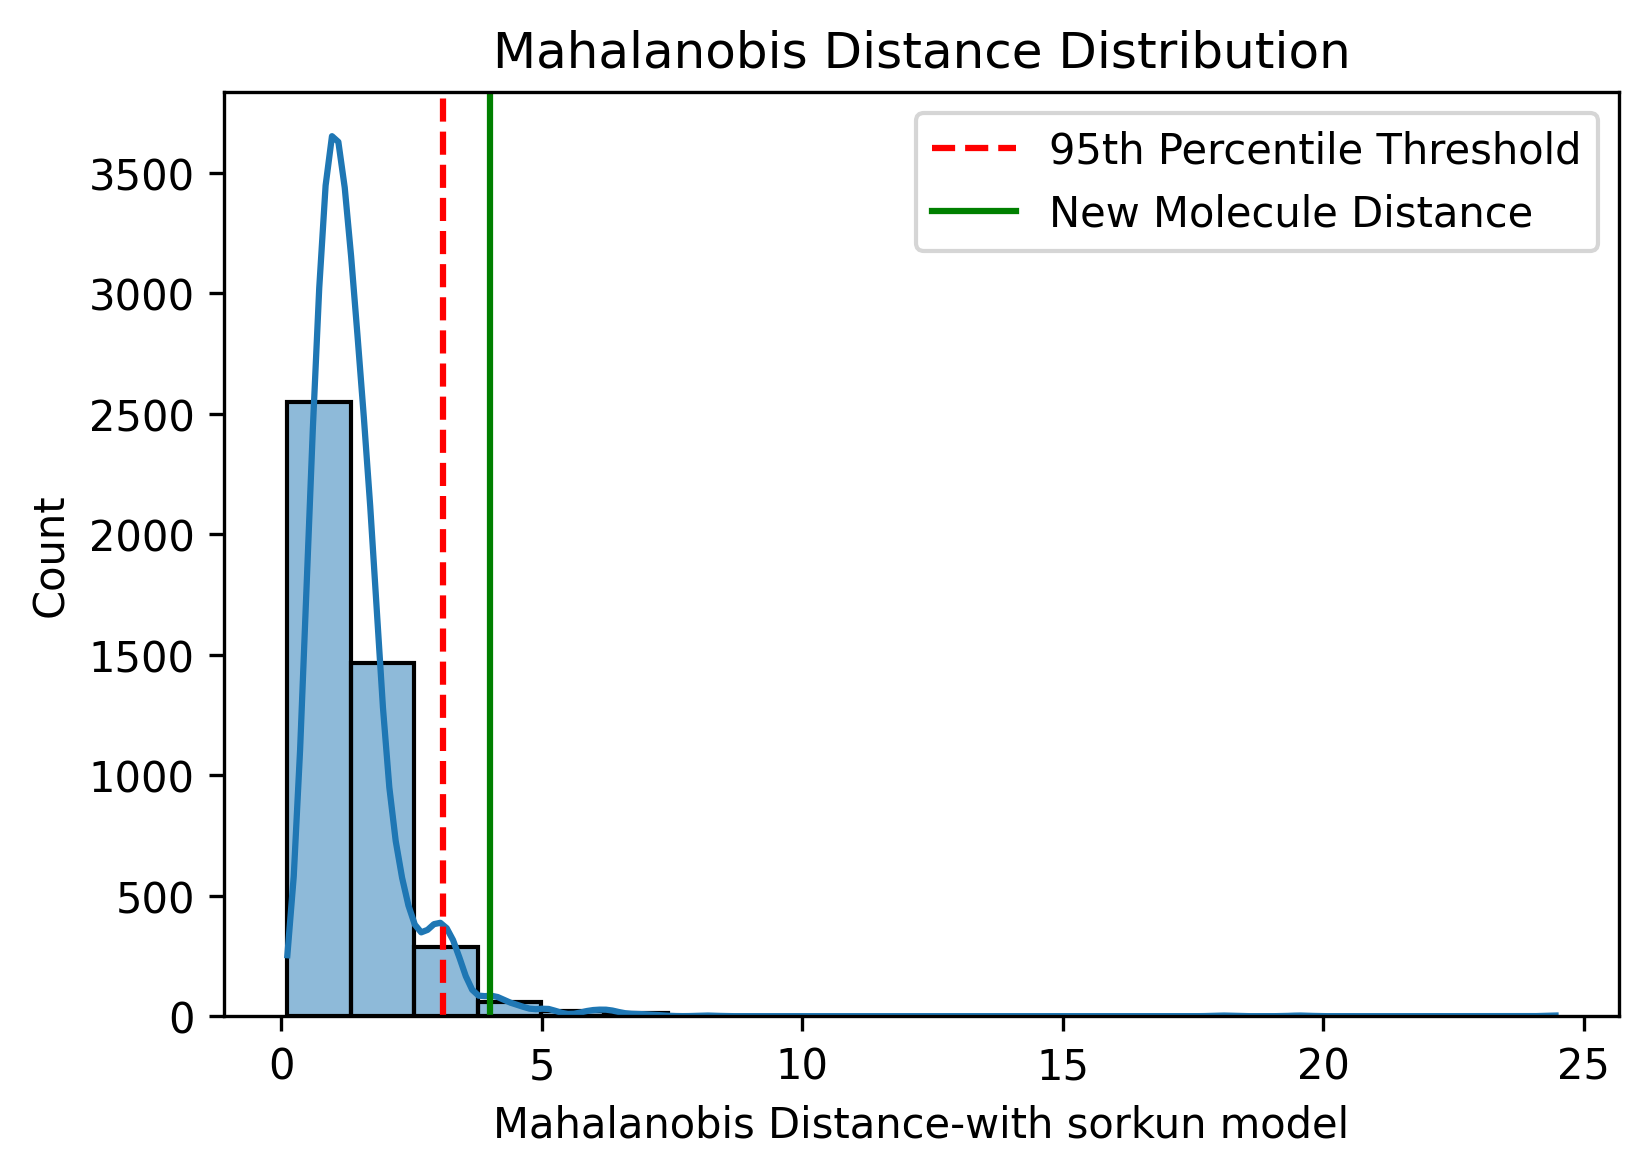

In [12]:
## for mw 588
import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
from scipy.spatial.distance import mahalanobis
from scipy.stats import median_abs_deviation
import pandas as pd

###creating vector for new compound 
SMILES='[C@H]1(C5=C([C@H](C2[C@@H]1C(OC2)=O)O[C@@H]3O[C@H]4[C@H]([C@@H]([C@H]3O)O)O[C@@H](OC4)C)C=C6C(=C5)OCO6)C7=CC(=C(C(=C7)OC)O)OC'
single_df=utilities.calculate_descriptors_sorkun(SMILES)

single_df=pd.DataFrame([single_df])
new_molecule_vector=utilities.clean_data(single_df)
###creating sorkun data training vector to compare 

### Laoding the sorkun train data 4355
train_sorkun=pd.read_csv('/Users/mushtaqali/Desktop/Solubility /Solubility_Paper/data/Sorkun_train.csv')
### Taking out the sorkun data smiles 
SMILES_sorkun=train_sorkun.smiles

sorkun_train= [utilities.calculate_descriptors_sorkun(smiles) for smiles in SMILES_sorkun]
df_sorkun_train = pd.DataFrame(sorkun_train)
training_set_vectors=utilities.clean_data(df_sorkun_train)
### Standardize Data (Important for PCA & Mahalanobis)

scaler = StandardScaler()
training_set_vectors_scaled = scaler.fit_transform(training_set_vectors)
new_molecule_vector_scaled = scaler.transform(new_molecule_vector)


#  Compute t-SNE Embeddings (Only for Visualization)

tsne = TSNE(n_components=3, random_state=42, perplexity=50)
training_set_vectors_tsne3 = tsne.fit_transform(training_set_vectors_scaled)


# Reduce Dimensionality with PCA for Mahalanobis Distance

pca = PCA(n_components=3)  # Use 3D PCA for meaningful distance calculations
training_set_vectors_pca3 = pca.fit_transform(training_set_vectors_scaled)


# Approximate New Molecule PCA Coordinates Using k-NN Regression

knn = KNeighborsRegressor(n_neighbors=5, weights="uniform")
knn.fit(training_set_vectors_scaled, training_set_vectors_pca3)
new_molecule_pca3 = knn.predict(new_molecule_vector_scaled).flatten()


# Compute Mahalanobis Distance in PCA Space

# Compute covariance matrix using Ledoit-Wolf for stability
cov_matrix = LedoitWolf().fit(training_set_vectors_pca3).covariance_
inv_cov_matrix = np.linalg.inv(cov_matrix)

# Compute mean in PCA space
mean_pca = np.mean(training_set_vectors_pca3, axis=0)

# Compute Mahalanobis distances of training molecules
distances = [mahalanobis(t, mean_pca, inv_cov_matrix) for t in training_set_vectors_pca3]

# Compute Mahalanobis distance of new molecule
new_molecule_distance = mahalanobis(new_molecule_pca3, mean_pca, inv_cov_matrix)


#  Compute Applicability Domain Threshold

# Compute 90th percentile instead of MAD for better robustness
threshold_distance = np.percentile(distances, 95)


# Decision Based on Mahalanobis Distance

print(f"New molecule Mahalanobis distance (PCA space): {new_molecule_distance:.3f}")
print(f"Applicability threshold (95th percentile): {threshold_distance:.3f}")

if new_molecule_distance > threshold_distance:
    print("New molecule is OUTSIDE the applicability domain!")
else:
    print("New molecule is WITHIN the applicability domain!")

# Plot Mahalanobis Distance Distribution
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Force full transparency
fig.patch.set_alpha(0)  # Make the entire figure background transparent
ax.set_facecolor("none")  # Remove background color from axes

sns.histplot(distances, bins=20, kde=True)
plt.axvline(threshold_distance, color='red', linestyle='dashed', label="95th Percentile Threshold")
plt.axvline(new_molecule_distance, color='green', linestyle='solid', label="New Molecule Distance")
plt.xlabel("Mahalanobis Distance-with sorkun model")
plt.ylabel("Count")
plt.legend()
plt.title("Mahalanobis Distance Distribution")
plt.savefig(
    "mahalanobis_distance_sorkun_model.png",
    dpi=300,
    bbox_inches='tight',
    transparent=True,
    facecolor=fig.get_facecolor()  # Ensure background is removed
)

plt.savefig('mahalanobis_distance_sorkun_model.png', dpi=300,transparent=True,facecolor="none")

plt.show()

In [15]:
### End here 
print("complete")